# Clustering

In [2]:
import pandas as pd 
data=pd.read_csv('cleaned_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392857 entries, 0 to 392856
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   InvoiceNo         392857 non-null  object 
 1   StockCode         392857 non-null  object 
 2   Description       392857 non-null  object 
 3   Quantity          392857 non-null  int64  
 4   InvoiceDate       392857 non-null  object 
 5   UnitPrice         392857 non-null  float64
 6   CustomerID        392857 non-null  int64  
 7   Country           392857 non-null  object 
 8   QuantityCanceled  392857 non-null  int64  
 9   TotalPrice        392857 non-null  float64
 10  Cluster           392857 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 33.0+ MB


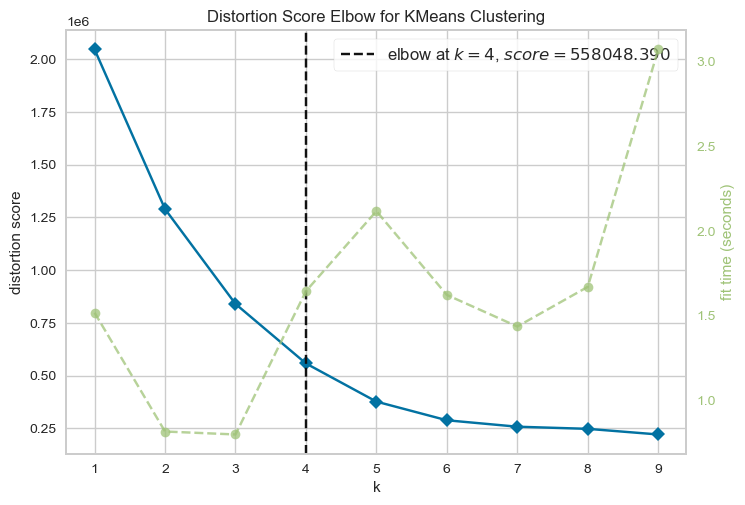

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from yellowbrick.cluster import KElbowVisualizer
import warnings

warnings.filterwarnings('ignore')

# Handle missing values if any
data = data.dropna()

# Select appropriate columns for clustering
data_cluster = data[['Quantity', 'QuantityCanceled', 'Country', 'InvoiceDate']]

# Convert the InvoiceDate column to datetime and extract information
data_cluster['InvoiceDate'] = pd.to_datetime(data_cluster['InvoiceDate'])
data_cluster['Year'] = data_cluster['InvoiceDate'].dt.year
data_cluster['Month'] = data_cluster['InvoiceDate'].dt.month
data_cluster['Day'] = data_cluster['InvoiceDate'].dt.day

# Select numerical columns and categorical columns
numeric_features = ['Quantity', 'QuantityCanceled', 'Year', 'Month', 'Day']
categorical_features = ['Country']

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

# Normalize the data
data_pro = preprocessor.fit_transform(data_cluster)

# Convert csr_matrix to a NumPy array
data_pro = data_pro.toarray()

# Create a KMeans model to determine the number of clusters
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1, 10))
visualizer.fit(data_pro)  # Match the data with the visualization tool
visualizer.show()



In [4]:
# Initialize and train the K-means model with k=4
kmeans = KMeans(n_clusters=4, random_state=0)
data['Cluster'] = kmeans.fit_predict(data_pro)

# View the assigned clusters
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,QuantityCanceled,TotalPrice,Cluster
0,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,74215,0.0,1
1,549222,22375,AIRLINE BAG VINTAGE JET SET BROWN,4,2011-04-07 10:43:00,4.25,12347,Iceland,0,17.0,2
2,573511,22698,PINK REGENCY TEACUP AND SAUCER,12,2011-10-31 12:25:00,2.95,12347,Iceland,0,35.4,0
3,573511,47559B,TEA TIME OVEN GLOVE,10,2011-10-31 12:25:00,1.25,12347,Iceland,0,12.5,0
4,573511,47567B,TEA TIME KITCHEN APRON,6,2011-10-31 12:25:00,5.95,12347,Iceland,0,35.7,0
...,...,...,...,...,...,...,...,...,...,...,...
392852,554065,22064,PINK DOUGHNUT TRINKET POT,12,2011-05-22 10:39:00,1.65,18287,United Kingdom,0,19.8,0
392853,554065,21232,STRAWBERRY CERAMIC TRINKET BOX,12,2011-05-22 10:39:00,1.25,18287,United Kingdom,0,15.0,0
392854,554065,22644,CERAMIC CHERRY CAKE MONEY BANK,12,2011-05-22 10:39:00,1.45,18287,United Kingdom,0,17.4,0
392855,554065,21556,CERAMIC STRAWBERRY MONEY BOX,12,2011-05-22 10:39:00,2.55,18287,United Kingdom,0,30.6,0


In [5]:
cluster_map={
    0:'Cluster 1',
    1:'Cluster 2',
    2:'Cluster 3',
    3:'Cluster 4'
}
data['Cluster']=data['Cluster'].map(cluster_map)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392857 entries, 0 to 392856
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   InvoiceNo         392857 non-null  object 
 1   StockCode         392857 non-null  object 
 2   Description       392857 non-null  object 
 3   Quantity          392857 non-null  int64  
 4   InvoiceDate       392857 non-null  object 
 5   UnitPrice         392857 non-null  float64
 6   CustomerID        392857 non-null  int64  
 7   Country           392857 non-null  object 
 8   QuantityCanceled  392857 non-null  int64  
 9   TotalPrice        392857 non-null  float64
 10  Cluster           392857 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 33.0+ MB


In [18]:
data.to_csv('cleaned_data.csv', index=False)